Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Using Colab cache for faster access to the 'student-performance-data-set' dataset.
Datasets downloaded successfully.

Dataset 1 — Shape: (1000, 8)
Missing values: 0
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             

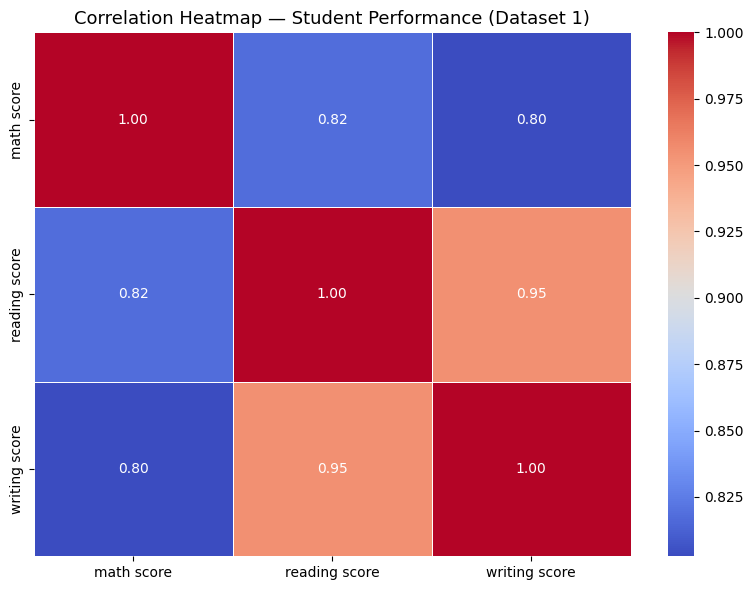


Encoded Dataset 1 — Shape: (1000, 15)

Dataset 1 Results:
  R² Score : 0.8804
  MSE      : 29.10


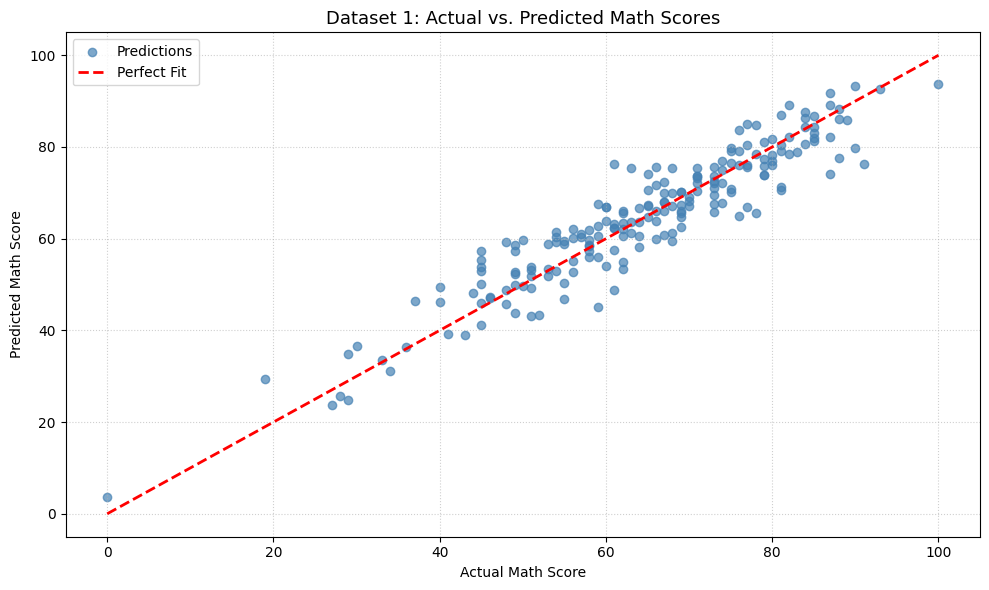


Dataset 2 — Shape: (649, 33)
Missing values: 0
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


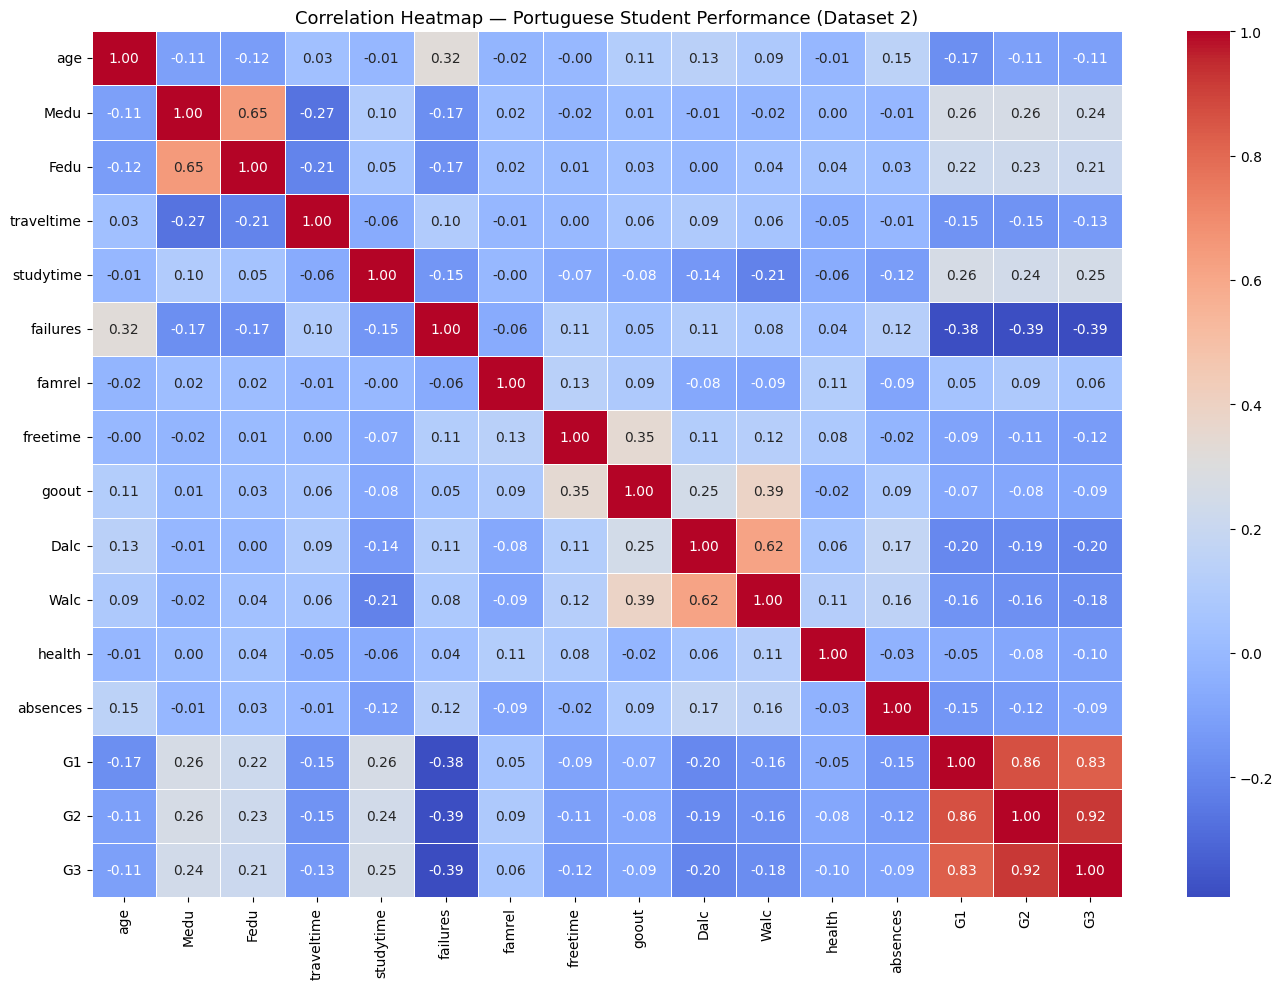


Dataset 2 Results:
  R² Score : 0.8487
  MSE      : 1.48


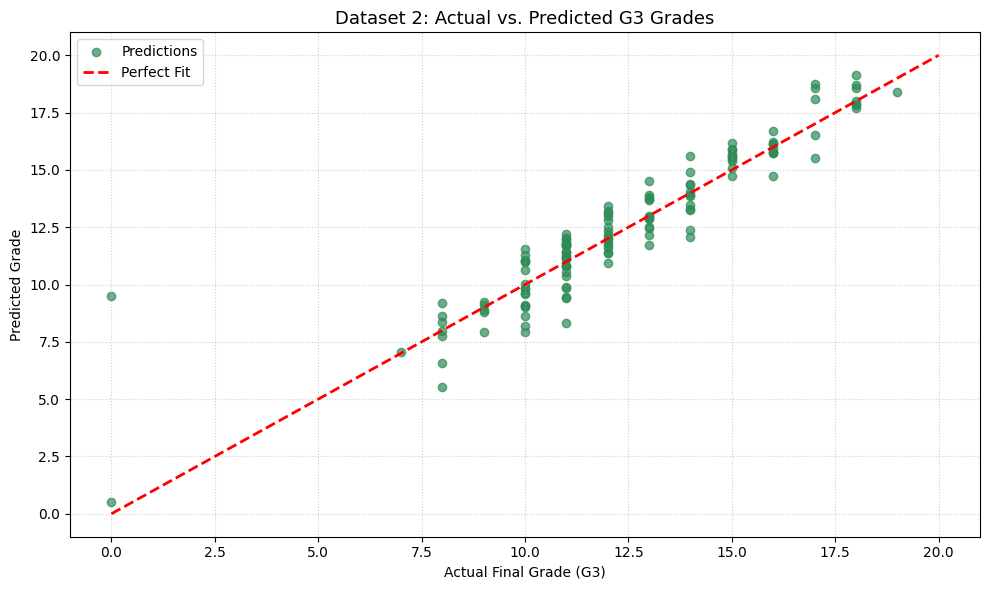


=== Model Performance Summary ===
Dataset 1 (Math Score Prediction)  — R²: 0.8804  |  MSE: 29.10
Dataset 2 (Final Grade Prediction) — R²: 0.8487  |  MSE: 1.48


In [3]:

# Student Performance Analysis
# Author: Arya Kothari
# Description: Exploratory data analysis and predictive modeling
#              on two student performance datasets using Linear Regression.

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#  Kaggle Dataset Setup
import kagglehub

path_ds1 = kagglehub.dataset_download('spscientist/students-performance-in-exams')
path_ds2 = kagglehub.dataset_download('larsen0966/student-performance-data-set')

print("Datasets downloaded successfully.")

# DATASET 1 — Students Performance in Exams

df1 = pd.read_csv(f'{path_ds1}/StudentsPerformance.csv')

print(f"\nDataset 1 — Shape: {df1.shape}")
print(f"Missing values: {df1.isnull().sum().max()}")
print(df1.head())

plt.figure(figsize=(8, 6))
numeric_cols_1 = df1.select_dtypes(include='number')
correlation_matrix_1 = numeric_cols_1.corr()

sns.heatmap(
    correlation_matrix_1,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlation Heatmap — Student Performance (Dataset 1)', fontsize=13)
plt.tight_layout()
plt.show()

# Encode categorical columns (gender, lunch, test prep, etc.)
df1_encoded = pd.get_dummies(df1, drop_first=True)
print(f"\nEncoded Dataset 1 — Shape: {df1_encoded.shape}")

features_1 = df1_encoded.drop('math score', axis=1)
target_1   = df1_encoded['math score']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    features_1, target_1, test_size=0.2, random_state=42
)

reg_model_1 = LinearRegression()
reg_model_1.fit(X1_train, y1_train)
y1_pred = reg_model_1.predict(X1_test)

r2_1  = r2_score(y1_test, y1_pred)
mse_1 = mean_squared_error(y1_test, y1_pred)

print(f"\nDataset 1 Results:")
print(f"  R² Score : {r2_1:.4f}")
print(f"  MSE      : {mse_1:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y1_test, y1_pred, alpha=0.7, color='steelblue', label='Predictions')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.title('Dataset 1: Actual vs. Predicted Math Scores', fontsize=13)
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# DATASET 2 — Portuguese Student Performance
df2 = pd.read_csv(f'{path_ds2}/student-por.csv')
print(f"\nDataset 2 — Shape: {df2.shape}")
print(f"Missing values: {df2.isnull().sum().max()}")
print(df2.head())

plt.figure(figsize=(14, 10))
numeric_cols_2 = df2.select_dtypes(include='number')
correlation_matrix_2 = numeric_cols_2.corr()

sns.heatmap(
    correlation_matrix_2,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlation Heatmap — Portuguese Student Performance (Dataset 2)', fontsize=13)
plt.tight_layout()
plt.show()

df2_encoded = pd.get_dummies(df2, drop_first=True)

features_2 = df2_encoded.drop('G3', axis=1)
target_2   = df2_encoded['G3']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    features_2, target_2, test_size=0.2, random_state=42
)

reg_model_2 = LinearRegression()
reg_model_2.fit(X2_train, y2_train)
y2_pred = reg_model_2.predict(X2_test)

r2_2  = r2_score(y2_test, y2_pred)
mse_2 = mean_squared_error(y2_test, y2_pred)

print(f"\nDataset 2 Results:")
print(f"  R² Score : {r2_2:.4f}")
print(f"  MSE      : {mse_2:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y2_test, y2_pred, alpha=0.7, color='seagreen', label='Predictions')
plt.plot([0, 20], [0, 20], color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.title('Dataset 2: Actual vs. Predicted G3 Grades', fontsize=13)
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Predicted Grade')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Summary
print("\n=== Model Performance Summary ===")
print(f"Dataset 1 (Math Score Prediction)  — R²: {r2_1:.4f}  |  MSE: {mse_1:.2f}")
print(f"Dataset 2 (Final Grade Prediction) — R²: {r2_2:.4f}  |  MSE: {mse_2:.2f}")